In [1]:
import sys
sys.path.append('/home/maria/Documents/projects/anomaly_detection_vehicles')

### DRAEM

In [3]:
import yaml

with open("/home/maria/Documents/projects/anomaly_detection_vehicles/environment.yml") as file_handle:
    environment_data = yaml.load(file_handle)

with open("/home/maria/Documents/projects/anomaly_detection_vehicles/requirements.txt", "w") as file_handle:
    for dependency in environment_data["dependencies"]:
        package_name, package_version = dependency.split("=")
        file_handle.write("{} == {}".format(package_name, package_version))

TypeError: load() missing 1 required positional argument: 'Loader'

In [2]:
#configurations

train_image_path = '/home/maria/Documents/dataset_splited/agco_dataset/train/'
anomaly_source_path = '/home/maria/Documents/datasets/dtd/images/'
checkpoint_path = '/home/maria/Documents/projects/anomaly_detection_vehicles/checkpoints_scratch/'
run_name = 'TEST_FIELD_1_'
resize_image = (224, 224*2)
batch_size = 1
lr = 0.0001
epochs = 100

### Dataloader

In [3]:
import torch

from torchvision.datasets import ImageFolder
from torchvision.transforms import transforms

import torchvision
import matplotlib.pyplot as plt
import numpy as np


from torch.utils.data import DataLoader
from data.field_dataloader import CustomTrainDataset


#### Model - train

In [4]:
from models.DRAEM import ReconstructiveSubNetwork, DiscriminativeSubNetwork
from losses.loss import FocalLoss, SSIM
from torch import optim
import os

In [5]:
#lets test output,inout
model = ReconstructiveSubNetwork()  
input_image = torch.randn(1, 3, 224, 224*2)  
output_image = model(input_image)
print(output_image.shape)  

torch.Size([1, 3, 224, 448])


In [6]:
#lets test output,inout
model = DiscriminativeSubNetwork()  
input_image = torch.randn(1, 3, 224, 224*2)  
output_image = model(input_image)
print(output_image.shape)  

torch.Size([1, 3, 224, 448])


In [7]:
def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group['lr']

def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        m.weight.data.normal_(0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        m.weight.data.normal_(1.0, 0.02)
        m.bias.data.fill_(0)


def save_images(images, titles, flags, n_iter, epoch, run_name, figsize=(10, 10)):
    output_dir = os.path.join(run_name, "visualisations", str(epoch))
    os.makedirs(output_dir, exist_ok=True)

    for i, (img, title, flag) in enumerate(zip(images, titles, flags)):
        plt.figure(figsize=figsize)
        
        img_np = img.detach().cpu().numpy().transpose(1, 2, 0)  # Convert (C, H, W) to (H, W, C)

        if flag is None:
            plt.imshow(np.clip(img_np, 0, 1))
        else:
            plt.imshow(np.clip(img_np, 0, 1), cmap=flag)

        #plt.title(f"{title} (Iter {n_iter})")
        plt.axis("off")

        filename = os.path.join(output_dir, f"{n_iter}_{title.replace(' ', '_')}.png")
        plt.savefig(filename, bbox_inches='tight')
        plt.close()

    #print(f"images saved to {output_dir}")


def visualize_images(images, titles, n_iter, figsize=(15, 5)):

    plt.figure(figsize=figsize)
    num_images = len(images)

    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(1, num_images, i + 1)
        
        img_np = img.detach().cpu().numpy().transpose(1, 2, 0)  
        plt.imshow(np.clip(img_np, 0, 1))
        plt.title(f"{title} (Iter {n_iter})")
        plt.axis("off")

    plt.show()


In [8]:
model = ReconstructiveSubNetwork(in_channels=3, out_channels=3)
model.cuda()
model.apply(weights_init)

model_seg = DiscriminativeSubNetwork(in_channels=6, out_channels=2)
model_seg.cuda()
model_seg.apply(weights_init)

DiscriminativeSubNetwork(
  (encoder_segment): EncoderDiscriminative(
    (block1): Sequential(
      (0): Conv2d(6, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
    (mp1): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (block2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_sta

In [9]:
model = ReconstructiveSubNetwork(in_channels=3, out_channels=3)
#model.apply(weights_init)
model.load_state_dict(torch.load("/home/maria/Documents/projects/anomaly_detection_vehicles/checkpoints_scratch/TEST_DRAEM_9epoch_90.pckl"))

#model.load_state_dict(torch.load("/home/maria/Documents/projects/anomaly_detection_vehicles/checkpoints/DRAEM_seg_large_ae_large_0.0001_800_bs8_carpet_.pckl"))
model.cuda()
#model.eval()

model_seg = DiscriminativeSubNetwork(in_channels=6, out_channels=2)
#model_seg.load_state_dict(torch.load("/home/maria/Documents/projects/anomaly_detection_vehicles/checkpoints/DRAEM_seg_large_ae_large_0.0001_800_bs8_carpet__seg.pckl"))
model_seg.load_state_dict(torch.load("/home/maria/Documents/projects/anomaly_detection_vehicles/checkpoints_scratch/TEST_DRAEM_9epoch_90_seg.pckl"))

model_seg.cuda()

DiscriminativeSubNetwork(
  (encoder_segment): EncoderDiscriminative(
    (block1): Sequential(
      (0): Conv2d(6, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
    (mp1): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (block2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_sta

In [10]:
# python train_DRAEM.py --gpu_id 0 --obj_id -1 --lr 0.0001 --bs 8 --epochs 700 --data_path ./datasets/mvtec/ --anomaly_source_path ./datasets/dtd/images/ --checkpoint_path ./checkpoints/ --log_path ./logs/
optimizer = torch.optim.Adam([
                                {"params": model.parameters(), "lr": lr},
                                {"params": model_seg.parameters(), "lr": lr}])

scheduler = optim.lr_scheduler.MultiStepLR(optimizer,[epochs*0.8, epochs*0.9],gamma=0.2, last_epoch=-1)

loss_l2 = torch.nn.modules.loss.MSELoss()
loss_ssim = SSIM()
loss_focal = FocalLoss()

In [11]:
dataset = CustomTrainDataset(image_dir=train_image_path, anomaly_source_dir=anomaly_source_path, resize_shape=resize_image)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=6)

Epoch: 73
Image 0 - L2 Loss: 0.0027 | SSIM Loss: 0.0642 | Segment Loss: 0.0001 | Total Loss: 0.0670


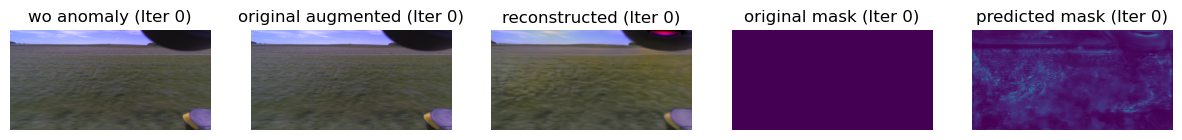

Image 10 - L2 Loss: 0.0131 | SSIM Loss: 0.1448 | Segment Loss: 0.0083 | Total Loss: 0.1661
Image 20 - L2 Loss: 0.0146 | SSIM Loss: 0.4444 | Segment Loss: 0.0520 | Total Loss: 0.5110
Image 30 - L2 Loss: 0.0102 | SSIM Loss: 0.1134 | Segment Loss: 0.0190 | Total Loss: 0.1427
Image 40 - L2 Loss: 0.0125 | SSIM Loss: 0.2670 | Segment Loss: 0.0002 | Total Loss: 0.2798
Image 50 - L2 Loss: 0.0071 | SSIM Loss: 0.2082 | Segment Loss: 0.0013 | Total Loss: 0.2166
Image 60 - L2 Loss: 0.0087 | SSIM Loss: 0.3861 | Segment Loss: 0.0012 | Total Loss: 0.3961
Image 70 - L2 Loss: 0.0063 | SSIM Loss: 0.3654 | Segment Loss: 0.0003 | Total Loss: 0.3720
Image 80 - L2 Loss: 0.0055 | SSIM Loss: 0.1353 | Segment Loss: 0.0002 | Total Loss: 0.1410
Image 90 - L2 Loss: 0.0076 | SSIM Loss: 0.0656 | Segment Loss: 0.0002 | Total Loss: 0.0734
Image 100 - L2 Loss: 0.0023 | SSIM Loss: 0.1690 | Segment Loss: 0.0001 | Total Loss: 0.1714


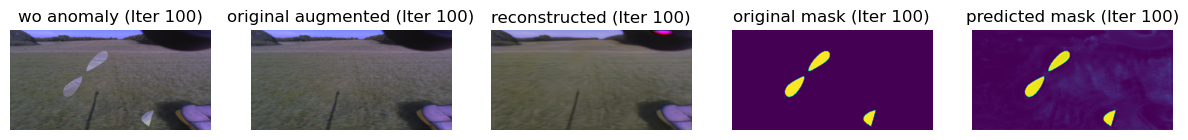

Image 110 - L2 Loss: 0.0074 | SSIM Loss: 0.3590 | Segment Loss: 0.0007 | Total Loss: 0.3671
Image 120 - L2 Loss: 0.0016 | SSIM Loss: 0.1616 | Segment Loss: 0.0005 | Total Loss: 0.1638
Image 130 - L2 Loss: 0.0047 | SSIM Loss: 0.0885 | Segment Loss: 0.0034 | Total Loss: 0.0966
Image 140 - L2 Loss: 0.0035 | SSIM Loss: 0.2375 | Segment Loss: 0.0018 | Total Loss: 0.2428
Image 150 - L2 Loss: 0.0055 | SSIM Loss: 0.2175 | Segment Loss: 0.0203 | Total Loss: 0.2433
Image 160 - L2 Loss: 0.0120 | SSIM Loss: 0.2497 | Segment Loss: 0.0020 | Total Loss: 0.2636
Image 170 - L2 Loss: 0.0051 | SSIM Loss: 0.2213 | Segment Loss: 0.0070 | Total Loss: 0.2334
Image 180 - L2 Loss: 0.0031 | SSIM Loss: 0.3290 | Segment Loss: 0.0072 | Total Loss: 0.3393
Image 190 - L2 Loss: 0.0038 | SSIM Loss: 0.1357 | Segment Loss: 0.0002 | Total Loss: 0.1397
Image 200 - L2 Loss: 0.0027 | SSIM Loss: 0.0615 | Segment Loss: 0.0002 | Total Loss: 0.0644


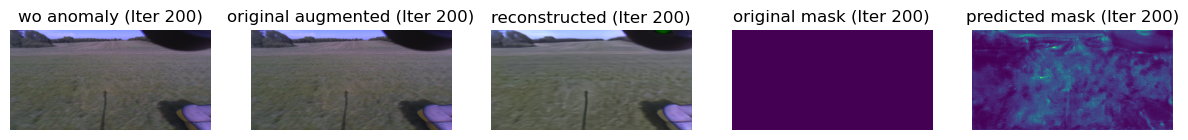

Image 210 - L2 Loss: 0.0032 | SSIM Loss: 0.1792 | Segment Loss: 0.0007 | Total Loss: 0.1832
Image 220 - L2 Loss: 0.0079 | SSIM Loss: 0.2425 | Segment Loss: 0.0198 | Total Loss: 0.2702
Image 230 - L2 Loss: 0.0021 | SSIM Loss: 0.1379 | Segment Loss: 0.0003 | Total Loss: 0.1403
Image 240 - L2 Loss: 0.0125 | SSIM Loss: 0.3263 | Segment Loss: 0.0013 | Total Loss: 0.3401
Image 250 - L2 Loss: 0.0020 | SSIM Loss: 0.2011 | Segment Loss: 0.0015 | Total Loss: 0.2046
Image 260 - L2 Loss: 0.0064 | SSIM Loss: 0.2301 | Segment Loss: 0.0340 | Total Loss: 0.2705
Image 270 - L2 Loss: 0.0057 | SSIM Loss: 0.3535 | Segment Loss: 0.0007 | Total Loss: 0.3599
Image 280 - L2 Loss: 0.0028 | SSIM Loss: 0.0491 | Segment Loss: 0.0003 | Total Loss: 0.0522
Image 290 - L2 Loss: 0.0015 | SSIM Loss: 0.1668 | Segment Loss: 0.0004 | Total Loss: 0.1687
Image 300 - L2 Loss: 0.0021 | SSIM Loss: 0.0681 | Segment Loss: 0.0001 | Total Loss: 0.0703


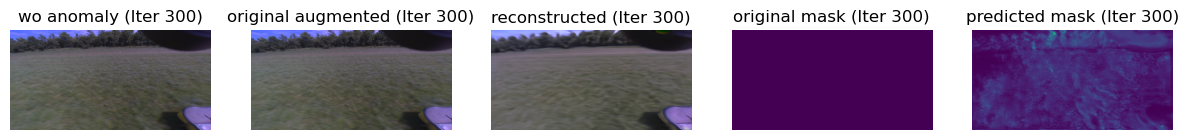

Image 310 - L2 Loss: 0.0013 | SSIM Loss: 0.1498 | Segment Loss: 0.0040 | Total Loss: 0.1551
Image 320 - L2 Loss: 0.0022 | SSIM Loss: 0.1530 | Segment Loss: 0.0023 | Total Loss: 0.1575
Image 330 - L2 Loss: 0.0031 | SSIM Loss: 0.1229 | Segment Loss: 0.0033 | Total Loss: 0.1293
Image 340 - L2 Loss: 0.0051 | SSIM Loss: 0.0800 | Segment Loss: 0.0285 | Total Loss: 0.1135
Image 350 - L2 Loss: 0.0061 | SSIM Loss: 0.3134 | Segment Loss: 0.0030 | Total Loss: 0.3225
Image 360 - L2 Loss: 0.0015 | SSIM Loss: 0.0694 | Segment Loss: 0.0008 | Total Loss: 0.0717
Image 370 - L2 Loss: 0.0030 | SSIM Loss: 0.1136 | Segment Loss: 0.0023 | Total Loss: 0.1189
Image 380 - L2 Loss: 0.0231 | SSIM Loss: 0.3579 | Segment Loss: 0.0748 | Total Loss: 0.4558
Image 390 - L2 Loss: 0.0036 | SSIM Loss: 0.2567 | Segment Loss: 0.0003 | Total Loss: 0.2605
Image 400 - L2 Loss: 0.0103 | SSIM Loss: 0.2461 | Segment Loss: 0.0004 | Total Loss: 0.2567


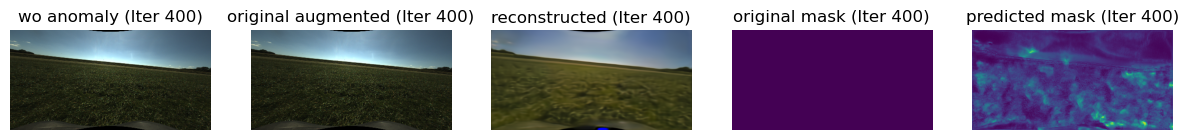

Image 410 - L2 Loss: 0.0029 | SSIM Loss: 0.0658 | Segment Loss: 0.0003 | Total Loss: 0.0690
Image 420 - L2 Loss: 0.0117 | SSIM Loss: 0.3078 | Segment Loss: 0.0007 | Total Loss: 0.3202
Image 430 - L2 Loss: 0.0056 | SSIM Loss: 0.3922 | Segment Loss: 0.0005 | Total Loss: 0.3983
Image 440 - L2 Loss: 0.0106 | SSIM Loss: 0.3399 | Segment Loss: 0.0138 | Total Loss: 0.3643
Image 450 - L2 Loss: 0.0028 | SSIM Loss: 0.0965 | Segment Loss: 0.0027 | Total Loss: 0.1020
Image 460 - L2 Loss: 0.0059 | SSIM Loss: 0.0777 | Segment Loss: 0.0159 | Total Loss: 0.0995
Image 470 - L2 Loss: 0.0148 | SSIM Loss: 0.2881 | Segment Loss: 0.0447 | Total Loss: 0.3477
Image 480 - L2 Loss: 0.0027 | SSIM Loss: 0.1801 | Segment Loss: 0.0023 | Total Loss: 0.1851
Image 490 - L2 Loss: 0.0018 | SSIM Loss: 0.0525 | Segment Loss: 0.0006 | Total Loss: 0.0548
Image 500 - L2 Loss: 0.0100 | SSIM Loss: 0.4040 | Segment Loss: 0.0043 | Total Loss: 0.4183


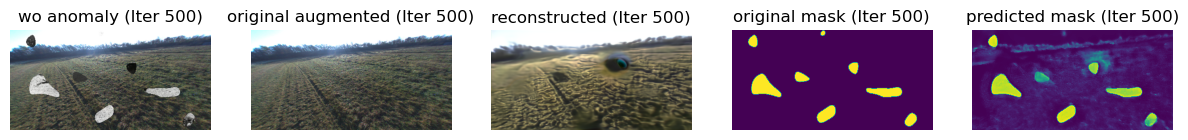

Image 510 - L2 Loss: 0.0017 | SSIM Loss: 0.2854 | Segment Loss: 0.0008 | Total Loss: 0.2879
Image 520 - L2 Loss: 0.0084 | SSIM Loss: 0.2805 | Segment Loss: 0.0074 | Total Loss: 0.2963
Image 530 - L2 Loss: 0.0062 | SSIM Loss: 0.1592 | Segment Loss: 0.0055 | Total Loss: 0.1709
Image 540 - L2 Loss: 0.0061 | SSIM Loss: 0.2179 | Segment Loss: 0.0050 | Total Loss: 0.2290
Image 550 - L2 Loss: 0.0028 | SSIM Loss: 0.0459 | Segment Loss: 0.0008 | Total Loss: 0.0495
Image 560 - L2 Loss: 0.0074 | SSIM Loss: 0.3709 | Segment Loss: 0.0064 | Total Loss: 0.3846
Image 570 - L2 Loss: 0.0079 | SSIM Loss: 0.2629 | Segment Loss: 0.0013 | Total Loss: 0.2721
Image 580 - L2 Loss: 0.0055 | SSIM Loss: 0.0586 | Segment Loss: 0.0009 | Total Loss: 0.0651
Image 590 - L2 Loss: 0.0026 | SSIM Loss: 0.1923 | Segment Loss: 0.0006 | Total Loss: 0.1956
Image 600 - L2 Loss: 0.0072 | SSIM Loss: 0.1784 | Segment Loss: 0.0005 | Total Loss: 0.1861


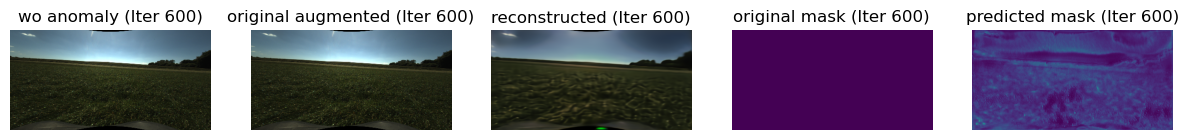

Image 610 - L2 Loss: 0.0025 | SSIM Loss: 0.2115 | Segment Loss: 0.0021 | Total Loss: 0.2161
Image 620 - L2 Loss: 0.0022 | SSIM Loss: 0.0576 | Segment Loss: 0.0073 | Total Loss: 0.0671
Image 630 - L2 Loss: 0.0029 | SSIM Loss: 0.3370 | Segment Loss: 0.0010 | Total Loss: 0.3409
Image 640 - L2 Loss: 0.0047 | SSIM Loss: 0.1284 | Segment Loss: 0.0003 | Total Loss: 0.1334
Image 650 - L2 Loss: 0.0129 | SSIM Loss: 0.2120 | Segment Loss: 0.0102 | Total Loss: 0.2351
Image 660 - L2 Loss: 0.0088 | SSIM Loss: 0.4260 | Segment Loss: 0.0011 | Total Loss: 0.4358
Image 670 - L2 Loss: 0.0068 | SSIM Loss: 0.0735 | Segment Loss: 0.0008 | Total Loss: 0.0811
Image 680 - L2 Loss: 0.0017 | SSIM Loss: 0.0846 | Segment Loss: 0.0029 | Total Loss: 0.0891
Image 690 - L2 Loss: 0.0065 | SSIM Loss: 0.2075 | Segment Loss: 0.0024 | Total Loss: 0.2164
Image 700 - L2 Loss: 0.0019 | SSIM Loss: 0.0495 | Segment Loss: 0.0076 | Total Loss: 0.0589


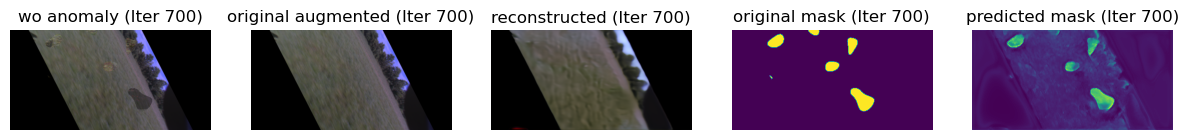

Image 710 - L2 Loss: 0.0213 | SSIM Loss: 0.4490 | Segment Loss: 0.0022 | Total Loss: 0.4724
Image 720 - L2 Loss: 0.0066 | SSIM Loss: 0.1327 | Segment Loss: 0.0015 | Total Loss: 0.1408
Image 730 - L2 Loss: 0.0068 | SSIM Loss: 0.4210 | Segment Loss: 0.0019 | Total Loss: 0.4297
Image 740 - L2 Loss: 0.0019 | SSIM Loss: 0.0694 | Segment Loss: 0.0247 | Total Loss: 0.0960
Image 750 - L2 Loss: 0.0040 | SSIM Loss: 0.0565 | Segment Loss: 0.0047 | Total Loss: 0.0652
Image 760 - L2 Loss: 0.0016 | SSIM Loss: 0.1197 | Segment Loss: 0.0004 | Total Loss: 0.1217
Image 770 - L2 Loss: 0.0019 | SSIM Loss: 0.1111 | Segment Loss: 0.0003 | Total Loss: 0.1134
Image 780 - L2 Loss: 0.0047 | SSIM Loss: 0.0797 | Segment Loss: 0.0015 | Total Loss: 0.0859
Image 790 - L2 Loss: 0.0040 | SSIM Loss: 0.0943 | Segment Loss: 0.0007 | Total Loss: 0.0990
Image 800 - L2 Loss: 0.0027 | SSIM Loss: 0.1166 | Segment Loss: 0.0010 | Total Loss: 0.1203


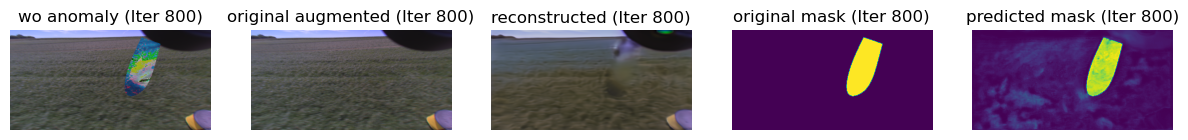

Image 810 - L2 Loss: 0.0021 | SSIM Loss: 0.1751 | Segment Loss: 0.0011 | Total Loss: 0.1782
Image 820 - L2 Loss: 0.0067 | SSIM Loss: 0.1134 | Segment Loss: 0.0056 | Total Loss: 0.1257
Image 830 - L2 Loss: 0.0100 | SSIM Loss: 0.3602 | Segment Loss: 0.0014 | Total Loss: 0.3716
Image 840 - L2 Loss: 0.0147 | SSIM Loss: 0.1345 | Segment Loss: 0.0112 | Total Loss: 0.1603
Image 850 - L2 Loss: 0.0072 | SSIM Loss: 0.2636 | Segment Loss: 0.0008 | Total Loss: 0.2716
Image 860 - L2 Loss: 0.0075 | SSIM Loss: 0.1403 | Segment Loss: 0.0170 | Total Loss: 0.1648
Image 870 - L2 Loss: 0.0024 | SSIM Loss: 0.1545 | Segment Loss: 0.0005 | Total Loss: 0.1574
Image 880 - L2 Loss: 0.0054 | SSIM Loss: 0.1062 | Segment Loss: 0.0005 | Total Loss: 0.1120
Image 890 - L2 Loss: 0.0020 | SSIM Loss: 0.1576 | Segment Loss: 0.0087 | Total Loss: 0.1683
Image 900 - L2 Loss: 0.0155 | SSIM Loss: 0.3216 | Segment Loss: 0.0200 | Total Loss: 0.3570


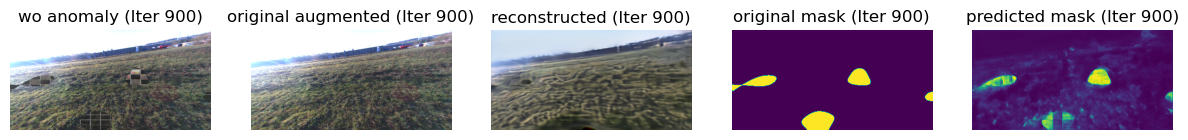

Image 910 - L2 Loss: 0.0100 | SSIM Loss: 0.4413 | Segment Loss: 0.0012 | Total Loss: 0.4524
Image 920 - L2 Loss: 0.0031 | SSIM Loss: 0.1627 | Segment Loss: 0.0010 | Total Loss: 0.1668
Image 930 - L2 Loss: 0.0046 | SSIM Loss: 0.3097 | Segment Loss: 0.0017 | Total Loss: 0.3161
Image 940 - L2 Loss: 0.0058 | SSIM Loss: 0.0787 | Segment Loss: 0.0009 | Total Loss: 0.0854
Image 950 - L2 Loss: 0.0106 | SSIM Loss: 0.2770 | Segment Loss: 0.0088 | Total Loss: 0.2964
Image 960 - L2 Loss: 0.0016 | SSIM Loss: 0.1324 | Segment Loss: 0.0006 | Total Loss: 0.1346
Image 970 - L2 Loss: 0.0019 | SSIM Loss: 0.0517 | Segment Loss: 0.0023 | Total Loss: 0.0559
Image 980 - L2 Loss: 0.0027 | SSIM Loss: 0.2222 | Segment Loss: 0.0025 | Total Loss: 0.2274
Image 990 - L2 Loss: 0.0036 | SSIM Loss: 0.1742 | Segment Loss: 0.0012 | Total Loss: 0.1791
Image 1000 - L2 Loss: 0.0353 | SSIM Loss: 0.2527 | Segment Loss: 0.0053 | Total Loss: 0.2933


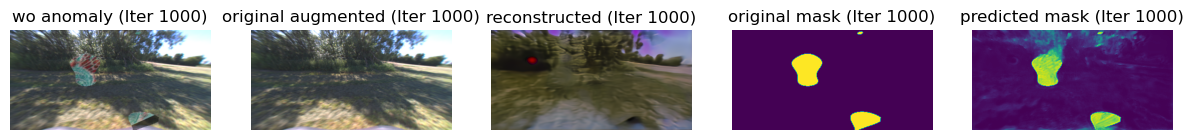

Image 1010 - L2 Loss: 0.0043 | SSIM Loss: 0.2219 | Segment Loss: 0.0004 | Total Loss: 0.2266
Image 1020 - L2 Loss: 0.0154 | SSIM Loss: 0.2880 | Segment Loss: 0.0903 | Total Loss: 0.3937
Image 1030 - L2 Loss: 0.0068 | SSIM Loss: 0.2285 | Segment Loss: 0.0018 | Total Loss: 0.2371
Image 1040 - L2 Loss: 0.0049 | SSIM Loss: 0.2487 | Segment Loss: 0.0302 | Total Loss: 0.2838
Image 1050 - L2 Loss: 0.0133 | SSIM Loss: 0.1873 | Segment Loss: 0.0005 | Total Loss: 0.2011
Image 1060 - L2 Loss: 0.0039 | SSIM Loss: 0.1093 | Segment Loss: 0.0011 | Total Loss: 0.1143
Image 1070 - L2 Loss: 0.0026 | SSIM Loss: 0.1333 | Segment Loss: 0.0052 | Total Loss: 0.1412
Image 1080 - L2 Loss: 0.0031 | SSIM Loss: 0.1147 | Segment Loss: 0.0010 | Total Loss: 0.1188
Image 1090 - L2 Loss: 0.0100 | SSIM Loss: 0.3886 | Segment Loss: 0.0019 | Total Loss: 0.4005
Image 1100 - L2 Loss: 0.0042 | SSIM Loss: 0.0660 | Segment Loss: 0.0020 | Total Loss: 0.0723


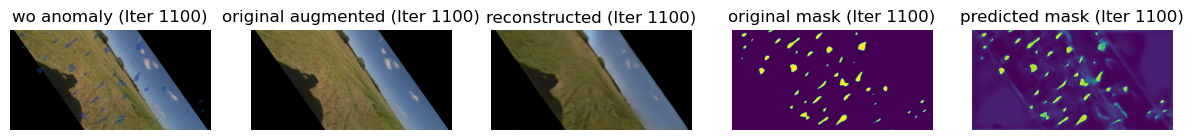

Image 1110 - L2 Loss: 0.0028 | SSIM Loss: 0.3309 | Segment Loss: 0.0005 | Total Loss: 0.3342
Image 1120 - L2 Loss: 0.0022 | SSIM Loss: 0.1419 | Segment Loss: 0.0142 | Total Loss: 0.1584
Image 1130 - L2 Loss: 0.0023 | SSIM Loss: 0.0445 | Segment Loss: 0.0003 | Total Loss: 0.0471
Image 1140 - L2 Loss: 0.0027 | SSIM Loss: 0.1002 | Segment Loss: 0.0007 | Total Loss: 0.1036
Image 1150 - L2 Loss: 0.0016 | SSIM Loss: 0.0707 | Segment Loss: 0.0004 | Total Loss: 0.0727
Image 1160 - L2 Loss: 0.0024 | SSIM Loss: 0.1565 | Segment Loss: 0.0004 | Total Loss: 0.1592
Image 1170 - L2 Loss: 0.0035 | SSIM Loss: 0.1856 | Segment Loss: 0.0003 | Total Loss: 0.1894
Image 1180 - L2 Loss: 0.0015 | SSIM Loss: 0.1623 | Segment Loss: 0.0003 | Total Loss: 0.1641
Image 1190 - L2 Loss: 0.0029 | SSIM Loss: 0.0431 | Segment Loss: 0.0002 | Total Loss: 0.0461
Image 1200 - L2 Loss: 0.0660 | SSIM Loss: 0.3818 | Segment Loss: 0.0012 | Total Loss: 0.4490


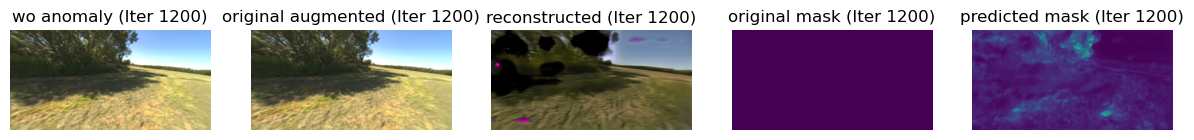

Image 1210 - L2 Loss: 0.0035 | SSIM Loss: 0.1711 | Segment Loss: 0.0003 | Total Loss: 0.1748
Image 1220 - L2 Loss: 0.0113 | SSIM Loss: 0.3489 | Segment Loss: 0.0015 | Total Loss: 0.3617
Image 1230 - L2 Loss: 0.0020 | SSIM Loss: 0.0540 | Segment Loss: 0.0011 | Total Loss: 0.0571
Image 1240 - L2 Loss: 0.0063 | SSIM Loss: 0.2667 | Segment Loss: 0.0058 | Total Loss: 0.2787
Image 1250 - L2 Loss: 0.0097 | SSIM Loss: 0.1203 | Segment Loss: 0.0007 | Total Loss: 0.1307
Image 1260 - L2 Loss: 0.0063 | SSIM Loss: 0.0793 | Segment Loss: 0.0711 | Total Loss: 0.1567
Image 1270 - L2 Loss: 0.0076 | SSIM Loss: 0.0638 | Segment Loss: 0.0016 | Total Loss: 0.0730
Image 1280 - L2 Loss: 0.0034 | SSIM Loss: 0.0784 | Segment Loss: 0.0047 | Total Loss: 0.0865
Image 1290 - L2 Loss: 0.0015 | SSIM Loss: 0.2699 | Segment Loss: 0.0060 | Total Loss: 0.2774
Image 1300 - L2 Loss: 0.0122 | SSIM Loss: 0.2965 | Segment Loss: 0.0444 | Total Loss: 0.3531


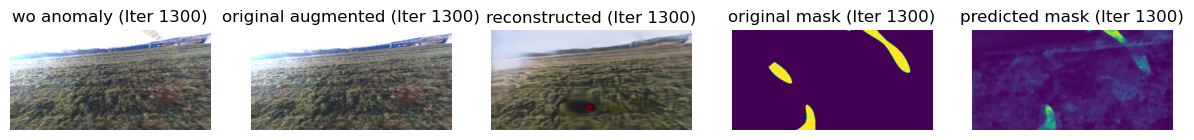

Image 1310 - L2 Loss: 0.0044 | SSIM Loss: 0.1850 | Segment Loss: 0.0010 | Total Loss: 0.1904
Image 1320 - L2 Loss: 0.0019 | SSIM Loss: 0.0624 | Segment Loss: 0.0004 | Total Loss: 0.0648
Image 1330 - L2 Loss: 0.0054 | SSIM Loss: 0.2214 | Segment Loss: 0.0127 | Total Loss: 0.2395
Image 1340 - L2 Loss: 0.0016 | SSIM Loss: 0.1156 | Segment Loss: 0.0005 | Total Loss: 0.1177
Image 1350 - L2 Loss: 0.0036 | SSIM Loss: 0.1314 | Segment Loss: 0.0007 | Total Loss: 0.1357
Image 1360 - L2 Loss: 0.0020 | SSIM Loss: 0.1318 | Segment Loss: 0.0003 | Total Loss: 0.1341
Image 1370 - L2 Loss: 0.0066 | SSIM Loss: 0.0739 | Segment Loss: 0.0002 | Total Loss: 0.0807
Image 1380 - L2 Loss: 0.0142 | SSIM Loss: 0.3922 | Segment Loss: 0.0020 | Total Loss: 0.4084
Image 1390 - L2 Loss: 0.0070 | SSIM Loss: 0.2427 | Segment Loss: 0.0018 | Total Loss: 0.2515
Image 1400 - L2 Loss: 0.0031 | SSIM Loss: 0.1744 | Segment Loss: 0.0005 | Total Loss: 0.1780


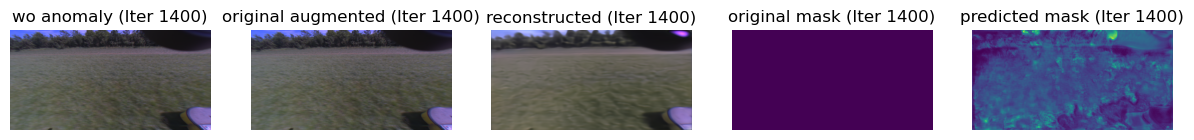

Image 1410 - L2 Loss: 0.0018 | SSIM Loss: 0.1602 | Segment Loss: 0.0023 | Total Loss: 0.1643
Image 1420 - L2 Loss: 0.0024 | SSIM Loss: 0.1264 | Segment Loss: 0.0005 | Total Loss: 0.1294
Image 1430 - L2 Loss: 0.0026 | SSIM Loss: 0.0947 | Segment Loss: 0.0003 | Total Loss: 0.0977
Image 1440 - L2 Loss: 0.0048 | SSIM Loss: 0.3637 | Segment Loss: 0.0088 | Total Loss: 0.3773
Image 1450 - L2 Loss: 0.0045 | SSIM Loss: 0.3540 | Segment Loss: 0.0012 | Total Loss: 0.3597
Image 1460 - L2 Loss: 0.0012 | SSIM Loss: 0.1658 | Segment Loss: 0.0018 | Total Loss: 0.1688
Image 1470 - L2 Loss: 0.0053 | SSIM Loss: 0.1652 | Segment Loss: 0.0007 | Total Loss: 0.1712
Image 1480 - L2 Loss: 0.0023 | SSIM Loss: 0.1237 | Segment Loss: 0.0002 | Total Loss: 0.1263
Image 1490 - L2 Loss: 0.0031 | SSIM Loss: 0.0632 | Segment Loss: 0.0002 | Total Loss: 0.0665
Image 1500 - L2 Loss: 0.0028 | SSIM Loss: 0.3379 | Segment Loss: 0.0025 | Total Loss: 0.3431


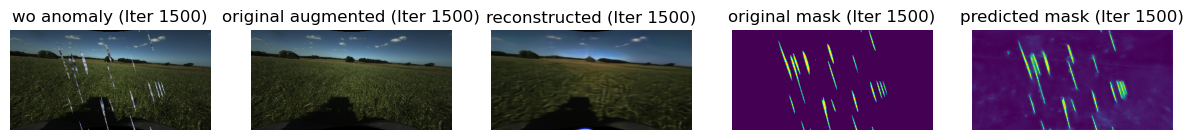

Image 1510 - L2 Loss: 0.0016 | SSIM Loss: 0.1513 | Segment Loss: 0.0003 | Total Loss: 0.1532
Image 1520 - L2 Loss: 0.0014 | SSIM Loss: 0.0490 | Segment Loss: 0.0003 | Total Loss: 0.0507
Image 1530 - L2 Loss: 0.0023 | SSIM Loss: 0.0499 | Segment Loss: 0.0002 | Total Loss: 0.0524
Image 1540 - L2 Loss: 0.0020 | SSIM Loss: 0.0358 | Segment Loss: 0.0003 | Total Loss: 0.0380
Image 1550 - L2 Loss: 0.0010 | SSIM Loss: 0.1674 | Segment Loss: 0.0003 | Total Loss: 0.1687
Image 1560 - L2 Loss: 0.0013 | SSIM Loss: 0.1000 | Segment Loss: 0.0144 | Total Loss: 0.1157
Image 1570 - L2 Loss: 0.0066 | SSIM Loss: 0.2071 | Segment Loss: 0.0003 | Total Loss: 0.2140
Image 1580 - L2 Loss: 0.0095 | SSIM Loss: 0.1414 | Segment Loss: 0.0007 | Total Loss: 0.1516
Image 1590 - L2 Loss: 0.0030 | SSIM Loss: 0.0425 | Segment Loss: 0.0002 | Total Loss: 0.0457
Image 1600 - L2 Loss: 0.0020 | SSIM Loss: 0.0485 | Segment Loss: 0.0006 | Total Loss: 0.0512


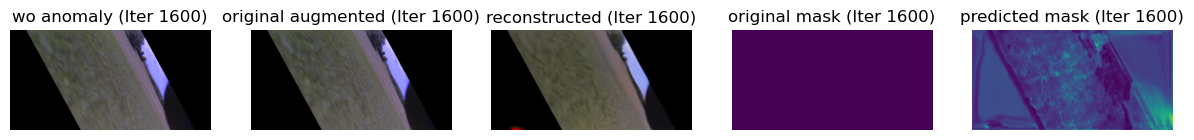

Image 1610 - L2 Loss: 0.0011 | SSIM Loss: 0.1293 | Segment Loss: 0.0056 | Total Loss: 0.1360
Image 1620 - L2 Loss: 0.0019 | SSIM Loss: 0.1216 | Segment Loss: 0.0002 | Total Loss: 0.1237
Image 1630 - L2 Loss: 0.0011 | SSIM Loss: 0.1372 | Segment Loss: 0.0003 | Total Loss: 0.1385
Image 1640 - L2 Loss: 0.0026 | SSIM Loss: 0.0450 | Segment Loss: 0.0002 | Total Loss: 0.0478
Image 1650 - L2 Loss: 0.0038 | SSIM Loss: 0.2267 | Segment Loss: 0.0007 | Total Loss: 0.2312
Image 1660 - L2 Loss: 0.0012 | SSIM Loss: 0.2417 | Segment Loss: 0.0003 | Total Loss: 0.2432
Image 1670 - L2 Loss: 0.0021 | SSIM Loss: 0.2886 | Segment Loss: 0.0073 | Total Loss: 0.2980
Image 1680 - L2 Loss: 0.0027 | SSIM Loss: 0.0405 | Segment Loss: 0.0004 | Total Loss: 0.0435
Image 1690 - L2 Loss: 0.0023 | SSIM Loss: 0.1837 | Segment Loss: 0.0022 | Total Loss: 0.1882
Image 1700 - L2 Loss: 0.0085 | SSIM Loss: 0.2823 | Segment Loss: 0.0148 | Total Loss: 0.3057


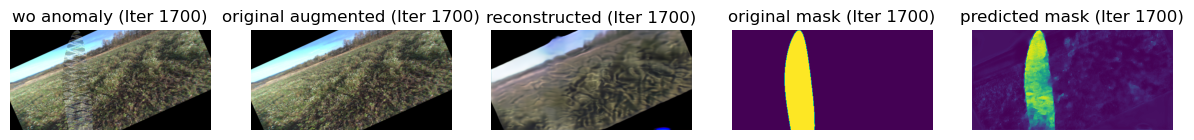

Image 1710 - L2 Loss: 0.0100 | SSIM Loss: 0.2886 | Segment Loss: 0.0511 | Total Loss: 0.3498
Image 1720 - L2 Loss: 0.0265 | SSIM Loss: 0.2197 | Segment Loss: 0.0042 | Total Loss: 0.2504
Image 1730 - L2 Loss: 0.0020 | SSIM Loss: 0.0669 | Segment Loss: 0.0008 | Total Loss: 0.0697
Image 1740 - L2 Loss: 0.0101 | SSIM Loss: 0.2907 | Segment Loss: 0.0005 | Total Loss: 0.3013
Image 1750 - L2 Loss: 0.0014 | SSIM Loss: 0.0592 | Segment Loss: 0.0002 | Total Loss: 0.0607
Image 1760 - L2 Loss: 0.0012 | SSIM Loss: 0.0534 | Segment Loss: 0.0005 | Total Loss: 0.0550
Image 1770 - L2 Loss: 0.0017 | SSIM Loss: 0.1901 | Segment Loss: 0.0004 | Total Loss: 0.1922
Image 1780 - L2 Loss: 0.0042 | SSIM Loss: 0.1480 | Segment Loss: 0.0004 | Total Loss: 0.1526
Image 1790 - L2 Loss: 0.0090 | SSIM Loss: 0.2585 | Segment Loss: 0.0003 | Total Loss: 0.2677
Image 1800 - L2 Loss: 0.0023 | SSIM Loss: 0.0777 | Segment Loss: 0.0017 | Total Loss: 0.0816


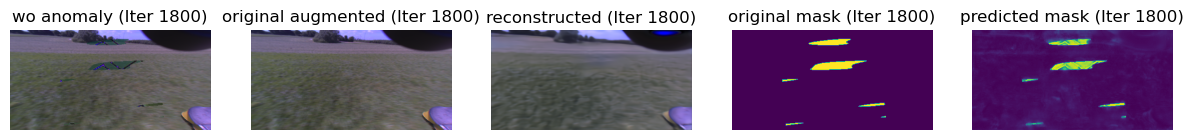

Image 1810 - L2 Loss: 0.0022 | SSIM Loss: 0.0616 | Segment Loss: 0.0001 | Total Loss: 0.0639
Image 1820 - L2 Loss: 0.0033 | SSIM Loss: 0.0656 | Segment Loss: 0.0002 | Total Loss: 0.0691
Image 1830 - L2 Loss: 0.0087 | SSIM Loss: 0.2411 | Segment Loss: 0.0008 | Total Loss: 0.2506
Image 1840 - L2 Loss: 0.0021 | SSIM Loss: 0.1475 | Segment Loss: 0.0071 | Total Loss: 0.1567
Image 1850 - L2 Loss: 0.0019 | SSIM Loss: 0.0642 | Segment Loss: 0.0021 | Total Loss: 0.0681
Image 1860 - L2 Loss: 0.0043 | SSIM Loss: 0.3230 | Segment Loss: 0.0014 | Total Loss: 0.3287
Image 1870 - L2 Loss: 0.0024 | SSIM Loss: 0.0925 | Segment Loss: 0.0023 | Total Loss: 0.0972
Image 1880 - L2 Loss: 0.0018 | SSIM Loss: 0.1531 | Segment Loss: 0.0011 | Total Loss: 0.1561
Image 1890 - L2 Loss: 0.0012 | SSIM Loss: 0.1811 | Segment Loss: 0.0007 | Total Loss: 0.1829
Image 1900 - L2 Loss: 0.0025 | SSIM Loss: 0.0833 | Segment Loss: 0.0008 | Total Loss: 0.0866


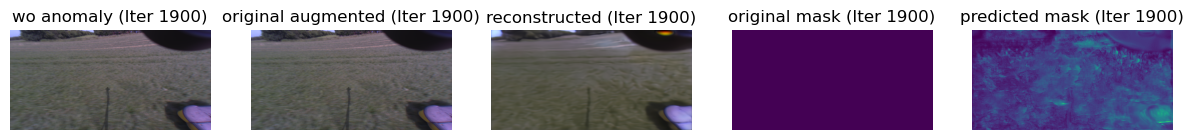

Image 1910 - L2 Loss: 0.0050 | SSIM Loss: 0.2150 | Segment Loss: 0.0035 | Total Loss: 0.2236
Image 1920 - L2 Loss: 0.0017 | SSIM Loss: 0.1387 | Segment Loss: 0.0003 | Total Loss: 0.1407
Image 1930 - L2 Loss: 0.0023 | SSIM Loss: 0.0634 | Segment Loss: 0.0005 | Total Loss: 0.0661
Image 1940 - L2 Loss: 0.0019 | SSIM Loss: 0.1122 | Segment Loss: 0.0005 | Total Loss: 0.1146
Image 1950 - L2 Loss: 0.0047 | SSIM Loss: 0.2037 | Segment Loss: 0.0147 | Total Loss: 0.2231
Image 1960 - L2 Loss: 0.0031 | SSIM Loss: 0.0482 | Segment Loss: 0.0018 | Total Loss: 0.0531
Image 1970 - L2 Loss: 0.0034 | SSIM Loss: 0.1280 | Segment Loss: 0.0028 | Total Loss: 0.1343
Image 1980 - L2 Loss: 0.0027 | SSIM Loss: 0.1564 | Segment Loss: 0.0227 | Total Loss: 0.1818
Image 1990 - L2 Loss: 0.0042 | SSIM Loss: 0.2043 | Segment Loss: 0.0009 | Total Loss: 0.2094
Image 2000 - L2 Loss: 0.0039 | SSIM Loss: 0.3367 | Segment Loss: 0.0016 | Total Loss: 0.3421


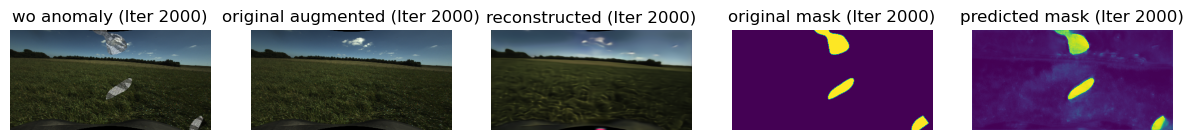

Image 2010 - L2 Loss: 0.0060 | SSIM Loss: 0.2324 | Segment Loss: 0.0013 | Total Loss: 0.2397


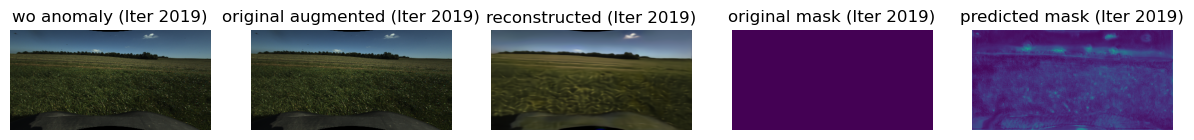

Epoch: 74
Image 2020 - L2 Loss: 0.0020 | SSIM Loss: 0.1746 | Segment Loss: 0.0006 | Total Loss: 0.1772
Image 2030 - L2 Loss: 0.0016 | SSIM Loss: 0.0732 | Segment Loss: 0.0004 | Total Loss: 0.0752
Image 2040 - L2 Loss: 0.0027 | SSIM Loss: 0.2824 | Segment Loss: 0.0008 | Total Loss: 0.2860
Image 2050 - L2 Loss: 0.0021 | SSIM Loss: 0.1775 | Segment Loss: 0.0018 | Total Loss: 0.1815
Image 2060 - L2 Loss: 0.0029 | SSIM Loss: 0.1691 | Segment Loss: 0.0026 | Total Loss: 0.1746
Image 2070 - L2 Loss: 0.0011 | SSIM Loss: 0.0599 | Segment Loss: 0.0005 | Total Loss: 0.0615
Image 2080 - L2 Loss: 0.0035 | SSIM Loss: 0.1448 | Segment Loss: 0.0072 | Total Loss: 0.1555
Image 2090 - L2 Loss: 0.0023 | SSIM Loss: 0.1852 | Segment Loss: 0.0004 | Total Loss: 0.1879
Image 2100 - L2 Loss: 0.0016 | SSIM Loss: 0.1103 | Segment Loss: 0.0044 | Total Loss: 0.1163


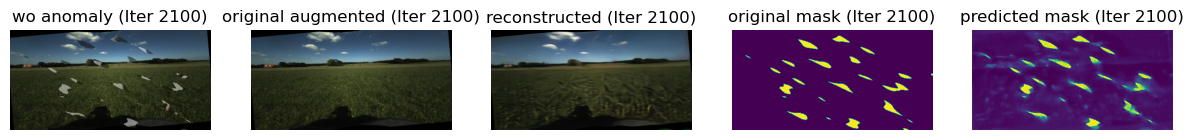

Image 2110 - L2 Loss: 0.0172 | SSIM Loss: 0.4122 | Segment Loss: 0.0104 | Total Loss: 0.4399
Image 2120 - L2 Loss: 0.0021 | SSIM Loss: 0.0726 | Segment Loss: 0.0003 | Total Loss: 0.0750
Image 2130 - L2 Loss: 0.0026 | SSIM Loss: 0.0673 | Segment Loss: 0.0004 | Total Loss: 0.0703
Image 2140 - L2 Loss: 0.0040 | SSIM Loss: 0.0760 | Segment Loss: 0.0051 | Total Loss: 0.0850
Image 2150 - L2 Loss: 0.0030 | SSIM Loss: 0.1275 | Segment Loss: 0.0030 | Total Loss: 0.1335
Image 2160 - L2 Loss: 0.0015 | SSIM Loss: 0.1249 | Segment Loss: 0.0003 | Total Loss: 0.1266
Image 2170 - L2 Loss: 0.0043 | SSIM Loss: 0.2310 | Segment Loss: 0.0004 | Total Loss: 0.2357
Image 2180 - L2 Loss: 0.0022 | SSIM Loss: 0.1862 | Segment Loss: 0.0063 | Total Loss: 0.1947
Image 2190 - L2 Loss: 0.0035 | SSIM Loss: 0.0762 | Segment Loss: 0.0012 | Total Loss: 0.0809
Image 2200 - L2 Loss: 0.0039 | SSIM Loss: 0.0576 | Segment Loss: 0.0044 | Total Loss: 0.0659


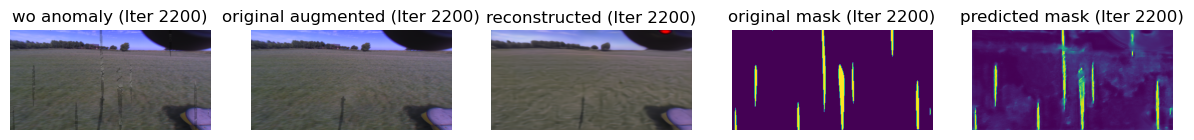

Image 2210 - L2 Loss: 0.0040 | SSIM Loss: 0.0499 | Segment Loss: 0.0011 | Total Loss: 0.0550
Image 2220 - L2 Loss: 0.0025 | SSIM Loss: 0.0535 | Segment Loss: 0.0400 | Total Loss: 0.0960
Image 2230 - L2 Loss: 0.0094 | SSIM Loss: 0.3461 | Segment Loss: 0.0031 | Total Loss: 0.3585
Image 2240 - L2 Loss: 0.0018 | SSIM Loss: 0.0651 | Segment Loss: 0.0010 | Total Loss: 0.0679
Image 2250 - L2 Loss: 0.0012 | SSIM Loss: 0.1279 | Segment Loss: 0.0003 | Total Loss: 0.1294
Image 2260 - L2 Loss: 0.0022 | SSIM Loss: 0.2170 | Segment Loss: 0.0007 | Total Loss: 0.2199
Image 2270 - L2 Loss: 0.0032 | SSIM Loss: 0.1964 | Segment Loss: 0.0006 | Total Loss: 0.2002
Image 2280 - L2 Loss: 0.0015 | SSIM Loss: 0.2221 | Segment Loss: 0.0013 | Total Loss: 0.2249
Image 2290 - L2 Loss: 0.0063 | SSIM Loss: 0.0980 | Segment Loss: 0.0011 | Total Loss: 0.1053
Image 2300 - L2 Loss: 0.0014 | SSIM Loss: 0.1001 | Segment Loss: 0.0005 | Total Loss: 0.1020


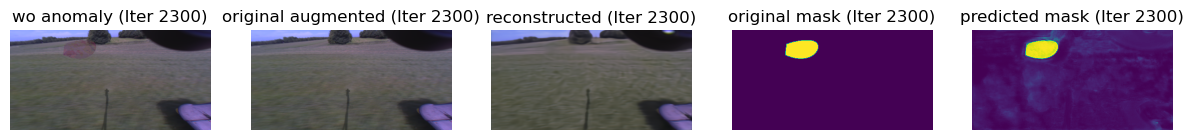

Image 2310 - L2 Loss: 0.0061 | SSIM Loss: 0.1397 | Segment Loss: 0.0003 | Total Loss: 0.1462
Image 2320 - L2 Loss: 0.0128 | SSIM Loss: 0.2054 | Segment Loss: 0.0023 | Total Loss: 0.2205
Image 2330 - L2 Loss: 0.0047 | SSIM Loss: 0.2452 | Segment Loss: 0.0644 | Total Loss: 0.3143
Image 2340 - L2 Loss: 0.0020 | SSIM Loss: 0.0683 | Segment Loss: 0.0009 | Total Loss: 0.0712
Image 2350 - L2 Loss: 0.0019 | SSIM Loss: 0.1130 | Segment Loss: 0.0003 | Total Loss: 0.1152
Image 2360 - L2 Loss: 0.0028 | SSIM Loss: 0.2103 | Segment Loss: 0.0008 | Total Loss: 0.2139
Image 2370 - L2 Loss: 0.0021 | SSIM Loss: 0.1916 | Segment Loss: 0.0024 | Total Loss: 0.1962
Image 2380 - L2 Loss: 0.0125 | SSIM Loss: 0.2780 | Segment Loss: 0.0013 | Total Loss: 0.2918
Image 2390 - L2 Loss: 0.0019 | SSIM Loss: 0.1334 | Segment Loss: 0.0004 | Total Loss: 0.1357
Image 2400 - L2 Loss: 0.0016 | SSIM Loss: 0.1617 | Segment Loss: 0.0002 | Total Loss: 0.1634


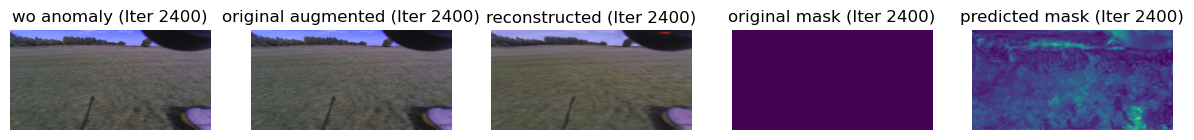

Image 2410 - L2 Loss: 0.0039 | SSIM Loss: 0.3196 | Segment Loss: 0.0003 | Total Loss: 0.3237
Image 2420 - L2 Loss: 0.0019 | SSIM Loss: 0.0918 | Segment Loss: 0.0002 | Total Loss: 0.0939
Image 2430 - L2 Loss: 0.0094 | SSIM Loss: 0.2556 | Segment Loss: 0.0005 | Total Loss: 0.2655
Image 2440 - L2 Loss: 0.0082 | SSIM Loss: 0.2680 | Segment Loss: 0.0066 | Total Loss: 0.2828
Image 2450 - L2 Loss: 0.0106 | SSIM Loss: 0.3817 | Segment Loss: 0.0209 | Total Loss: 0.4133
Image 2460 - L2 Loss: 0.0078 | SSIM Loss: 0.1826 | Segment Loss: 0.0007 | Total Loss: 0.1911
Image 2470 - L2 Loss: 0.0061 | SSIM Loss: 0.1737 | Segment Loss: 0.0049 | Total Loss: 0.1846
Image 2480 - L2 Loss: 0.0037 | SSIM Loss: 0.0780 | Segment Loss: 0.0007 | Total Loss: 0.0825
Image 2490 - L2 Loss: 0.0102 | SSIM Loss: 0.1244 | Segment Loss: 0.0010 | Total Loss: 0.1355
Image 2500 - L2 Loss: 0.0076 | SSIM Loss: 0.1724 | Segment Loss: 0.0041 | Total Loss: 0.1842


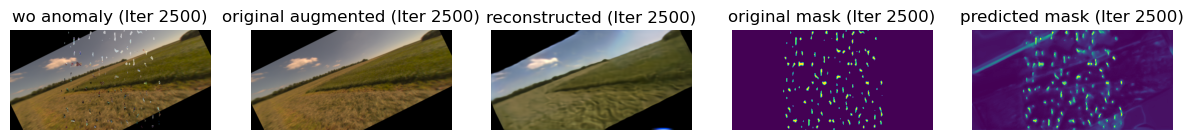

KeyboardInterrupt: 

: 

In [ ]:
import json

loss_history = []

n_iter = 0
for epoch in range(73, epochs):
    print(f"Epoch: {epoch}")
    for i_batch, sample_batched in enumerate(dataloader):
        gray_batch = sample_batched["image"].cuda()
        aug_gray_batch = sample_batched["augmented_image"].cuda()
        anomaly_mask = sample_batched["anomaly_mask"].cuda()

        gray_rec = model(aug_gray_batch)
        joined_in = torch.cat((gray_rec, aug_gray_batch), dim=1)

        out_mask = model_seg(joined_in)
        out_mask_sm = torch.softmax(out_mask, dim=1)

        l2_loss = loss_l2(gray_rec, gray_batch)
        ssim_loss = loss_ssim(gray_rec, gray_batch)

        segment_loss = loss_focal(out_mask_sm, anomaly_mask)
        loss = l2_loss + ssim_loss + segment_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Store the losses in the list
        loss_entry = {
            'iteration': n_iter,
            'epoch': epoch,
            'l2_loss': l2_loss.item(),
            'ssim_loss': ssim_loss.item(),
            'segment_loss': segment_loss.item(),
            'total_loss': loss.item()
        }
        loss_history.append(loss_entry)

        
        if n_iter%10 == 0:
            print(f"Image {n_iter} - L2 Loss: {l2_loss.item():.4f} | SSIM Loss: {ssim_loss.item():.4f} | Segment Loss: {segment_loss.item():.4f} | Total Loss: {loss.item():.4f}")

        # Visualize images
        if n_iter%200 == 0 or n_iter==2019:
            images = [aug_gray_batch[0], gray_batch[0], gray_rec[0], anomaly_mask[0], out_mask_sm[:, 1:, :, :][0]]
            titles = ["wo anomaly", "original augmented", "reconstructed", "original mask", "predicted mask"]
            flags = [None, None, None, 'grey', None]
            run_name = run_name

            save_images(images, titles, flags, n_iter, epoch, run_name)

        # Visualize images
        t_mask = out_mask_sm[:, 1:, :, :]

        if n_iter%100 == 0 or n_iter==2019:
          visualize_images(
              images=[aug_gray_batch[0], gray_batch[0], gray_rec[0], anomaly_mask[0], t_mask[0]],
              titles=["wo anomaly", "original augmented", "reconstructed", "original mask", "predicted mask"],
              n_iter=n_iter
          )
        n_iter +=1

    scheduler.step()

    # save checkpoints
    torch.save(model.state_dict(), os.path.join(checkpoint_path, run_name + ".pckl"))
    torch.save(model_seg.state_dict(), os.path.join(checkpoint_path, run_name + "_seg.pckl"))

# save the loss history
#loss_file_path = os.path.join(checkpoint_path, run_name + "_loss_history.json")
#with open(loss_file_path, 'w') as f:
#    json.dump(loss_history, f, indent=4)